In [ ]:
import os
import requests
import os

import numpy as np
import matplotlib.pyplot as plt
import glob
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import chi2
import scipy as s
import scipy.stats as sc
from scipy.stats import chi2 as chi2_dist
from scipy.stats import t,norm
plt.rcParams['text.usetex'] = False
try:
    import Uomo_lucertola_vecchia as lib2
    print('Successo Importazione')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola. Assicurati che 'Uomo_lucertola.py' sia nella stessa cartella del notebook: {os.getcwd()}")
try:
    import Uomo_lucertola as lib
    print('Successo Importazione 2')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola2. Assicurati che 'Uomo_lucertola2.py' sia nella stessa cartella del notebook: {os.getcwd()}")


import uncertainties
from uncertainties import ufloat, correlated_values
from uncertainties import ufloat
from uncertainties import unumpy

Successo Importazione
Successo Importazione 2


# **Errore sistematico stimato: 40.84 canali**

#  Analisi Per la stabilità

In [2]:
cartella_dati = "dati_stabilità"
pattern_ricerca = os.path.join(cartella_dati, "*.dat")
lista_file_completi = glob.glob(pattern_ricerca)
lista_file_completi.sort()
print(f"Trovati {len(lista_file_completi)} file da analizzare.")

Trovati 80 file da analizzare.


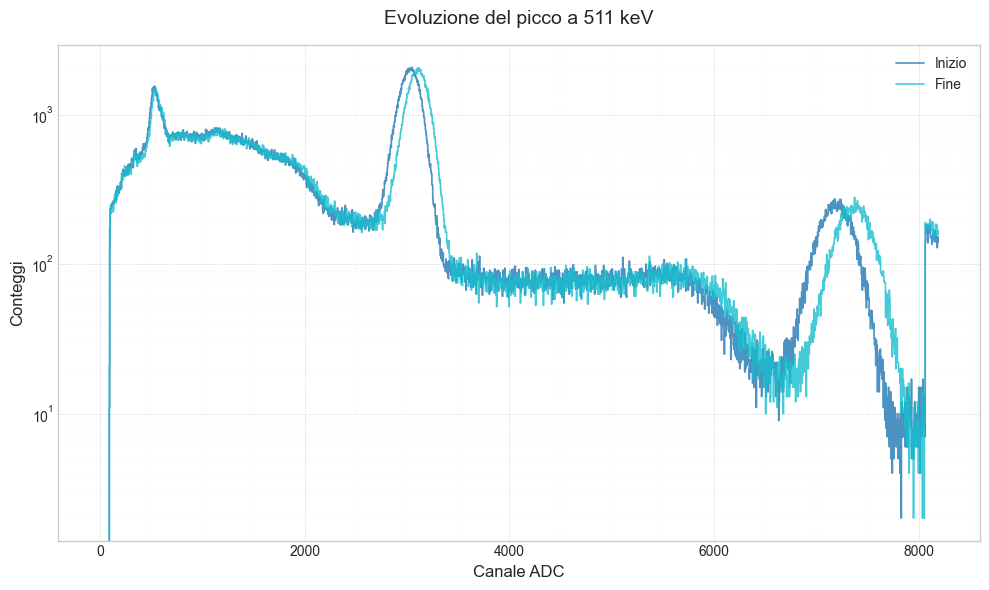

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Evoluzione del picco a 511 keV'}, xlabel='Canale ADC', ylabel='Conteggi'>)

In [3]:
lib.plot_multiple_spectra(
    [os.path.join(cartella_dati, "diff_ora_000_weekend30_aprile000.dat"), os.path.join(cartella_dati, "diff_ora_004_weekend30_aprile004.dat")],
    labels=["Inizio", "Fine"],
    log_scale=True,
    normalize= False,
    rebin_n=4,
    title="Evoluzione del picco a 511 keV"
)

In [4]:
c_v_max = 3400; c_v_min = 2800
risultati_stabilita = []

for i, percorso_completo in enumerate(lista_file_completi):
    filename = os.path.basename(percorso_completo)
    '''
    print(f"\n{'='*60}")
    print(f"  Analisi File [{i+1}/{len(lista_file_completi)}]: {filename}")
    print(f"{'='*60}")'''
    
    # Da qui in poi il codice è (quasi) identico al tuo!
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=4)

    mask = (canali >= c_v_min) & (canali <= c_v_max)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': c_guess,
        'x0': x0_guess
    }
    
    # Nota: se non vuoi stampare 80 grafici, passa show_hist=False al plot_results o commentalo
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf=lib.picco_esponenziale_cdf,
        modello_pdf=lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Misura Ora {i}"
    )
    fit.perform_fit(silent=True)
    
    #togliere il commento da questa riga per vedere un grafico per ogni file 
    # fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo', lib.funzione_esponenziale_pdf)])  
    
    if fit.is_fit_valid:
        mu_ufloat  = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig_ufloat = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        area_ufloat  = ufloat(fit.fit_result['Area'][0], fit.fit_result['Area'][1])
        
        # Salviamo l'ora (i) e i parametri ufloat
        risultati_stabilita.append((i, mu_ufloat, sig_ufloat, area_ufloat))
        
        #print(f"  → Centro del Picco = {mu_ufloat.n:.2f} ± {mu_ufloat.std_dev:.2f} canali")
        #print(f"  → Sigma = {sig_ufloat.n:.2f} ± {sig_ufloat.std_dev:.2f} canali")
    else:
        print(f"  ⚠️ Fit fallito per il file {filename}")


ore = np.array([r[0] for r in risultati_stabilita], dtype=float)
mu_values = np.array([r[1].n for r in risultati_stabilita])
mu_errors  = np.array([r[1].std_dev for r in risultati_stabilita])
sigma_values = np.array([r[2].n for r in risultati_stabilita])
sigma_errors  = np.array([r[2].std_dev for r in risultati_stabilita])
area_values = np.array([r[3].n for r in risultati_stabilita])
area_errors  = np.array([r[3].std_dev for r in risultati_stabilita])

print(len(mu_values), len(ore))

  ⚠️ Fit fallito per il file diff_ora_035_weekend30_aprile035.dat
79 79


## Grafico Picchi in Funzione del tempo


Differenza tra primo e ultimo picco: 28.03 ± 0.85
Delta dei canali: 81.68


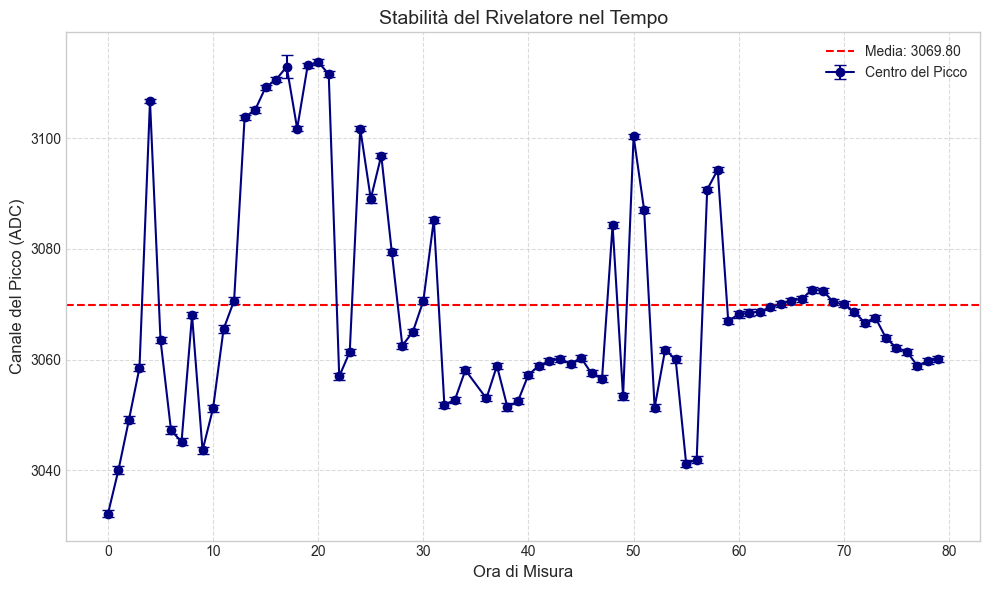

In [5]:
#Delta del centro del picco
primo_picco = risultati_stabilita[0][1].n
errore_primo = risultati_stabilita[0][1].std_dev

ultimo_picco = risultati_stabilita[-1][1].n 
errore_ultimo = risultati_stabilita[-1][1].std_dev

differenza = ultimo_picco - primo_picco
errore_differenza = np.sqrt(errore_ultimo**2 + errore_primo**2)
print(f"Differenza tra primo e ultimo picco: {differenza:.2f} ± {errore_differenza:.2f}")

delta = np.max(mu_values) - np.min(mu_values)
print(f"Delta dei canali: {delta:.2f}")

# Estrazione dei dati
ore = [ris[0] for ris in risultati_stabilita]
mu_val = [ris[1].n for ris in risultati_stabilita]
mu_err = [ris[1].std_dev for ris in risultati_stabilita]

plt.figure(figsize=(10, 6))
plt.errorbar(ore, mu_val, yerr=mu_err, fmt='o-', color='navy', capsize=4, label='Centro del Picco')

# Aggiunta di una linea per la media
media_mu = np.mean(mu_val)
plt.axhline(media_mu, color='red', linestyle='--', label=f'Media: {media_mu:.2f}')

plt.xlabel('Ora di Misura', fontsize=12)
plt.ylabel('Canale del Picco (ADC)', fontsize=12)
plt.title('Stabilità del Rivelatore nel Tempo', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Grafico della risoluzione/sigma nel tempo


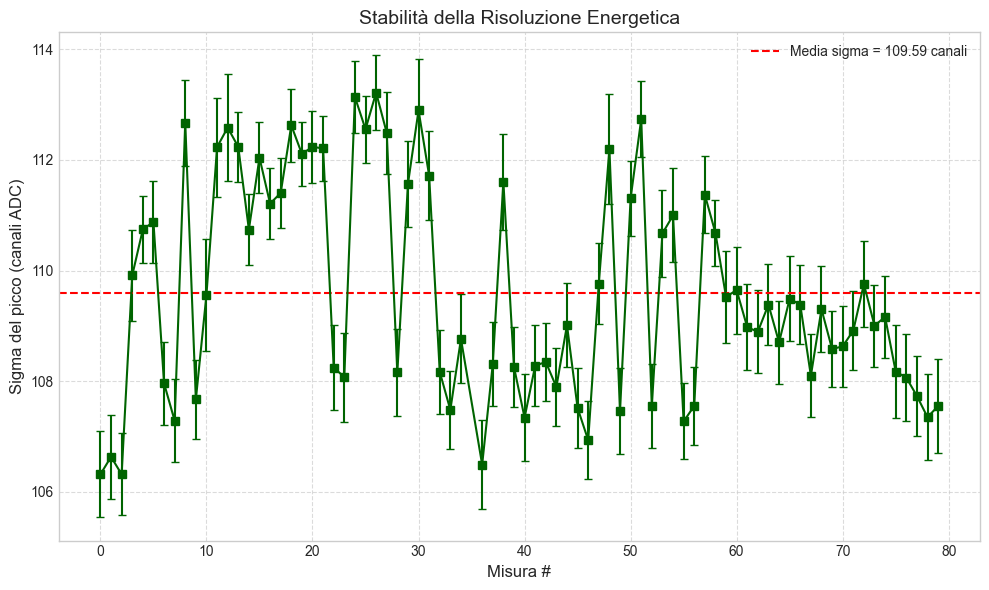

In [6]:
plt.figure(figsize=(10, 6))
plt.errorbar(ore, sigma_values, yerr=sigma_errors, fmt='s-', color='darkgreen', capsize=3)
plt.axhline(np.mean(sigma_values), color='red', linestyle='--', label=f'Media sigma = {np.mean(sigma_values):.2f} canali')
plt.xlabel('Misura #', fontsize=12)
plt.ylabel('Sigma del picco (canali ADC)', fontsize=12)
plt.title('Stabilità della Risoluzione Energetica', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Grafico dell'area normalizzata nel tempo

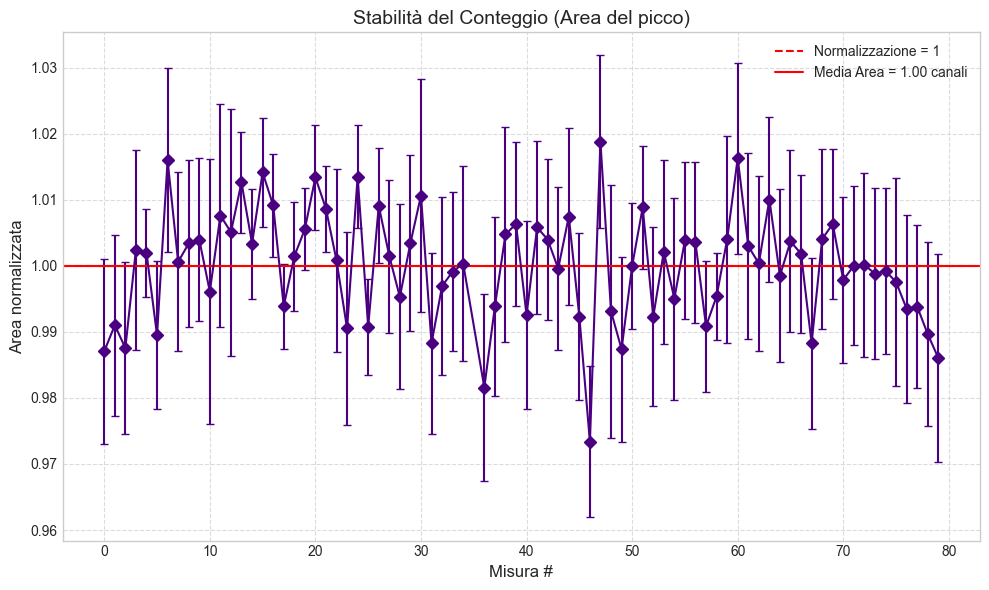

In [7]:
area_mean = np.mean(area_values)
area_norm = area_values / area_mean
area_norm_err = area_errors / area_mean

plt.figure(figsize=(10, 6))
plt.errorbar(ore, area_norm, yerr=area_norm_err, fmt='D-', color='indigo', capsize=3)
plt.axhline(1.0, color='red', linestyle='--', label='Normalizzazione = 1')
plt.axhline(np.mean(area_norm), color='red', linestyle='-', label=f'Media Area = {np.mean(area_norm):.2f} canali')
plt.xlabel('Misura #', fontsize=12)
plt.ylabel('Area normalizzata', fontsize=12)
plt.title('Stabilità del Conteggio (Area del picco)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Fit lineare del picco nel tempo

--- Esecuzione Fit con Metodo: LeastSquares ---
Fit completato.

--- Risultati del Fit (LeastSquares) ---
Fit Valido: Sì

Parametri Ottimizzati:
  a = 3081 ± 0.12
  b = -0.2158 ± 0.0027

Statistiche del Fit:
  Chi-quadro (χ²): 105568.8502
  Gradi di libertà (DoF): 77.0
  Chi-quadro Ridotto (χ²/DoF): 1371.0240
  p-value: 0.0000

Matrice di Covarianza (Minuit):


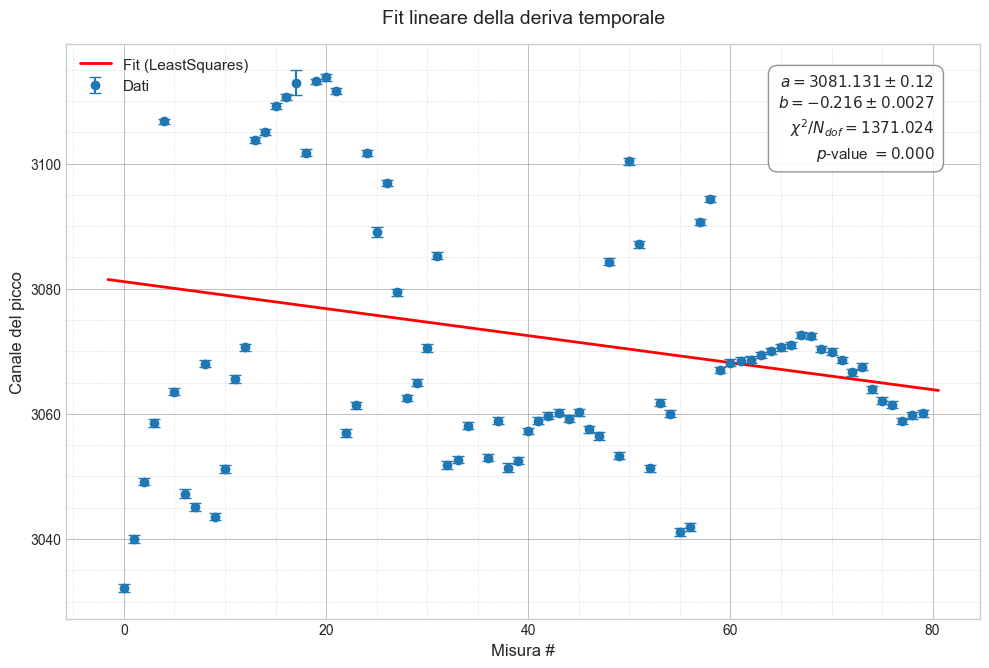

In [8]:
def retta(t, a, b):
    return a + b * t

data_deriv = {
    'x': ore,
    'y': mu_values,
    'sigma_y': mu_errors
}
init_deriv = {'a': np.mean(mu_values), 'b': 0.0}

fit_deriv = lib.FitBomberone(retta, data_deriv, init_deriv,
                             xlabel='Misura #', ylabel='Canale del picco',
                             title='Fit lineare della deriva temporale')
fit_deriv.perform_fit()
fit_deriv.print_results()
fit_deriv.plot_results()

Non è quindi compatibile con una costante, b non è compatibile con 0

Istogramma dei centroidi

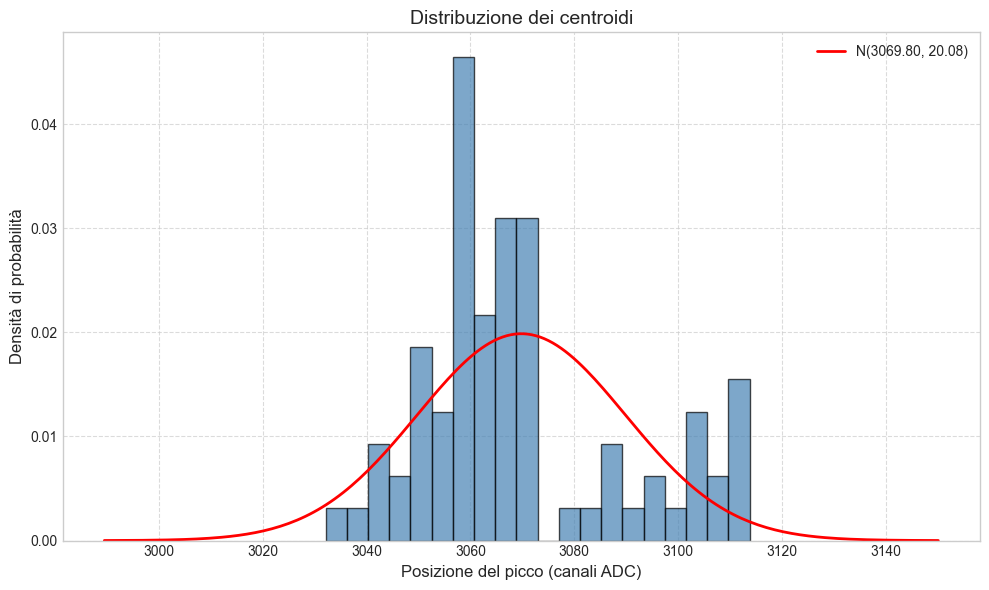

In [9]:
plt.figure(figsize=(10, 6))
# Istogramma dei valori di centroide
plt.hist(mu_values, bins=20, color='steelblue', edgecolor='black', alpha=0.7, density=True)

# Curva gaussiana di riferimento
from scipy.stats import norm
mu_media = np.mean(mu_values)
mu_std   = np.std(mu_values, ddof=1)
x_lim = np.linspace(mu_media - 4*mu_std, mu_media + 4*mu_std, 200)
plt.plot(x_lim, norm.pdf(x_lim, mu_media, mu_std), 'r-', linewidth=2,
         label=f'N({mu_media:.2f}, {mu_std:.2f})')

plt.xlabel('Posizione del picco (canali ADC)', fontsize=12)
plt.ylabel('Densità di probabilità', fontsize=12)
plt.title('Distribuzione dei centroidi', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Test compatibilità con costante

In [10]:
# Media pesata dei centroidi
media_pesata, err_media_pesata = lib.media_pesata(mu_values, mu_errors)

# Chi2 rispetto alla media pesata
chi2_stat = np.sum(((mu_values - media_pesata) / mu_errors)**2)
ndof = len(mu_values) - 1
p_val = sc.chi2.sf(chi2_stat, ndof)

print(f"Media pesata del centroide: {media_pesata:.2f} ± {err_media_pesata:.2f} canali")
print(f"Chi2 / ndof = {chi2_stat:.2f} / {ndof} = {chi2_stat/ndof:.2f}")
print(f"p-value = {p_val:.4f}")

Media pesata del centroide: 3072.52 ± 0.06 canali
Chi2 / ndof = 112201.40 / 78 = 1438.48
p-value = 0.0000


In [11]:
errore_sistematico = delta/2
print(f"Errore sistematico stimato: {errore_sistematico:.2f} canali")

Errore sistematico stimato: 40.84 canali
